# 激活函数

In [41]:
# 导入所需要的库
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## sigmoid

In [42]:
x = np.linspace(-10, 10, 1000)
y = tf.nn.sigmoid(x)

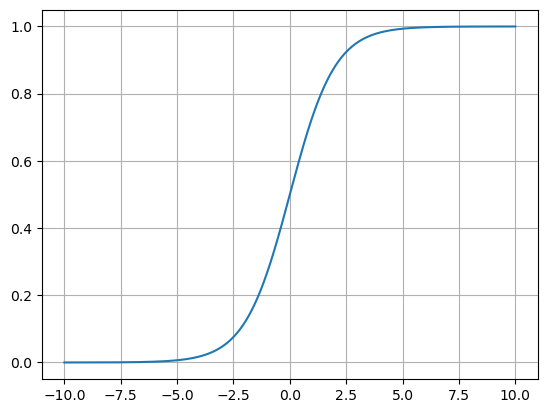

In [43]:
plt.plot(x, y)
plt.grid()

## tanh

In [44]:
x = np.linspace(-10, 10, 100)
y = tf.nn.tanh(x)

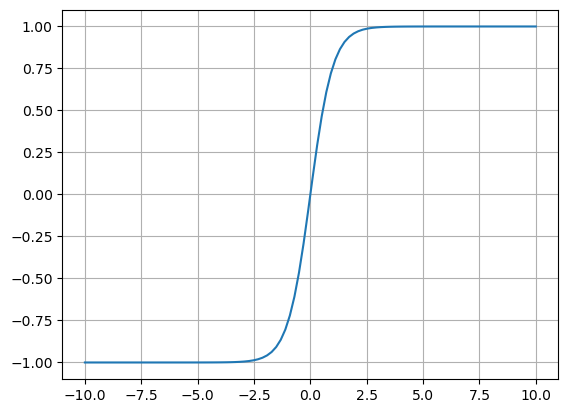

In [45]:
plt.plot(x, y)
plt.grid()

## relu

In [46]:
x = np.linspace(-10, 10, 100)
y = tf.nn.relu(x)

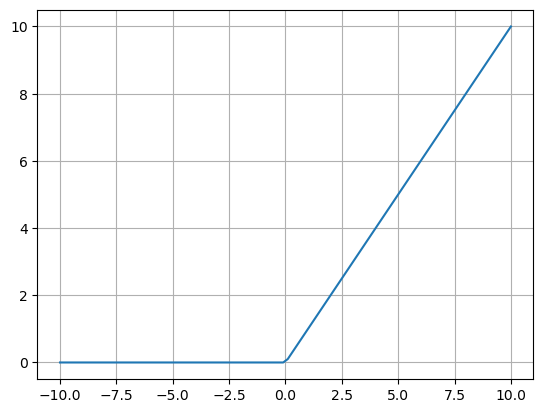

In [47]:
plt.plot(x, y)
plt.grid()

## leakyrelu

In [48]:
x = np.linspace(-10, 10, 100)
y = tf.nn.leaky_relu(x)

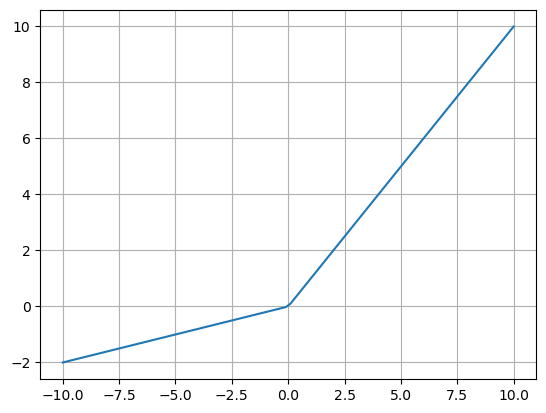

In [49]:
plt.plot(x, y)
plt.grid()

## softmax

In [50]:
x = tf.constant([0.2, 0.02, 0.15, 1.3, 0.5, 0.06, 1.1, 0.05, 3.75])
y = tf.nn.softmax(x)

In [51]:
y

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([0.02167152, 0.01810158, 0.02061459, 0.06510484, 0.02925349,
       0.01884031, 0.05330333, 0.01865285, 0.75445753], dtype=float32)>

# 参数初始化

In [52]:
import tensorflow as tf

## Xavizer初始化

In [53]:
# 正态分布的
# 实例化
initializer = tf.keras.initializers.glorot_normal()
values = initializer((9, 1))

In [54]:
values

<tf.Tensor: shape=(9, 1), dtype=float32, numpy=
array([[ 0.66919607],
       [ 0.13666275],
       [ 0.2567307 ],
       [ 0.1171454 ],
       [-0.371734  ],
       [-0.08053689],
       [-0.47764573],
       [ 0.2763095 ],
       [ 0.9849419 ]], dtype=float32)>

In [55]:
# 标准化：均匀分布
initializern = tf.keras.initializers.glorot_uniform()
values = initializern((9, 1))

In [56]:
values

<tf.Tensor: shape=(9, 1), dtype=float32, numpy=
array([[ 0.1867603 ],
       [-0.7255306 ],
       [-0.2505408 ],
       [ 0.37305498],
       [-0.1950267 ],
       [ 0.26701128],
       [ 0.6217823 ],
       [ 0.0589779 ],
       [-0.01298714]], dtype=float32)>

## He初始化

In [57]:
# 正态分布
# 实例化
initializer = tf.keras.initializers.he_normal()
# 采样得到权重
values = initializer((9, 1))

In [58]:
values

<tf.Tensor: shape=(9, 1), dtype=float32, numpy=
array([[ 0.25162455],
       [ 0.7951315 ],
       [-0.45162445],
       [ 0.50899124],
       [ 0.2578936 ],
       [-0.5913934 ],
       [-0.53662884],
       [-0.3221068 ],
       [ 0.6735606 ]], dtype=float32)>

In [59]:
# 标准化：均匀分布
initializer = tf.keras.initializers.he_uniform()
values = initializer((9, 1))

In [60]:
values

<tf.Tensor: shape=(9, 1), dtype=float32, numpy=
array([[ 0.386894  ],
       [-0.47289658],
       [-0.0258891 ],
       [ 0.65236974],
       [ 0.2072593 ],
       [ 0.44525445],
       [-0.61112076],
       [-0.6404909 ],
       [ 0.14315689]], dtype=float32)>

# 神经网络的搭建

## sequential方式

In [61]:
# 导入工具包
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers

print(tf.__version__)

2.12.0


In [62]:
# 定义model,构建模型
model = keras.Sequential([
    # 第一个隐层
    layers.Dense(3, activation="relu", kernel_initializer="he_normal", name="layer1", input_shape=(3,)),
    # 第二个隐层
    layers.Dense(2, activation="relu", kernel_initializer="he_normal", name="layer2"),
    # 输出层
    layers.Dense(2, activation="sigmoid", kernel_initializer="he_normal", name="layer3")
],
    name="sequential"
)

In [63]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              (None, 3)                 12        
                                                                 
 layer2 (Dense)              (None, 2)                 8         
                                                                 
 layer3 (Dense)              (None, 2)                 6         
                                                                 
Total params: 26
Trainable params: 26
Non-trainable params: 0
_________________________________________________________________


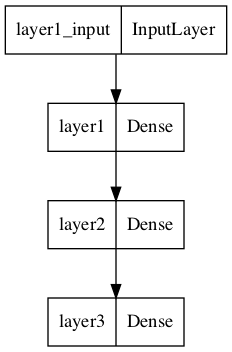

In [64]:
keras.utils.plot_model(model)


from tensorflow.keras.utils import plot_model

# 假设 model 是你的 Keras 模型
plot_model(model, to_file='model.png', show_shapes=True)## 利用functional API构建模型

In [65]:
# 定义模型的输入
inputs = keras.Input(shape=(3,), name='input')
# 第一个隐层
x = layers.Dense(3, activation="relu", name="layer1")(inputs)
# 第二个隐层
x = layers.Dense(2, activation="relu", name="layer2")(x)
# 输出层
outputs = layers.Dense(2, activation="sigmoid", name="output")(x)
# 创建模型
model = keras.Model(inputs=inputs, outputs=outputs,
                    name="Functional API Model")

In [66]:
model.summary()

Model: "Functional API Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 3)]               0         
                                                                 
 layer1 (Dense)              (None, 3)                 12        
                                                                 
 layer2 (Dense)              (None, 2)                 8         
                                                                 
 output (Dense)              (None, 2)                 6         
                                                                 
Total params: 26
Trainable params: 26
Non-trainable params: 0
_________________________________________________________________


4.0.1


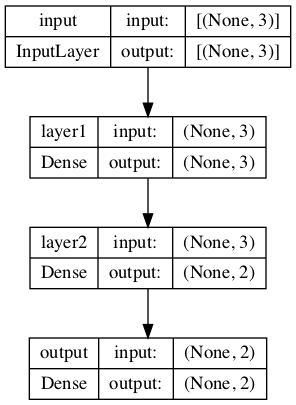

In [67]:
import pydot as pyd
print(pyd.__version__)
keras.utils.plot_model(model, show_shapes=True)

##  通过model子类构建模型

In [68]:
# 定义一个model的子类
class MyModel(keras.Model):
    # 定义网络的层结构
    def __init__(self):
        super(MyModel, self).__init__()
        # 第一层隐层
        self.layer1 = layers.Dense(3, activation="relu", name="layer1")
        # 第二个隐层
        self.layer2 = layers.Dense(2, activation="relu", name="layer2")
        # 输出层
        self.layer3 = layers.Dense(2, activation="sigmoid", name="layer3")

    # 定义网络的前向传播
    def call(self, inputs):
        x = self.layer1(inputs)
        x = self.layer2(x)
        outputs = self.layer3(x)
        return outputs

In [69]:
# 实例化moxing
model = MyModel()
# 设置输入
x = tf.ones((1, 3))
y = model(x)

In [70]:
y

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0.5, 0.5]], dtype=float32)>

In [71]:
model.summary()

Model: "my_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              multiple                  12        
                                                                 
 layer2 (Dense)              multiple                  8         
                                                                 
 layer3 (Dense)              multiple                  6         
                                                                 
Total params: 26
Trainable params: 26
Non-trainable params: 0
_________________________________________________________________


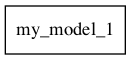

In [72]:
keras.utils.plot_model(model)

# 损失函数

## 交叉熵损失

In [73]:
import tensorflow as tf

In [74]:
# 设置真实值和预测值
y_true = [[0, 1, 0], [0, 0, 1]]
y_pre = [[0.05, 0.9, 0.05], [0.05, 0.05, 0.9]]
# 实例化交叉熵损失
cce = tf.keras.losses.CategoricalCrossentropy()
# 计算损失结果
cce(y_true, y_pre)

<tf.Tensor: shape=(), dtype=float32, numpy=0.10536054>

## 二分类的交叉熵损失函数

In [75]:
# 设置真实值和预测值
y_true = [[0], [1]]
y_pre = [[0.1], [0.9]]
# 实例化
bce = tf.keras.losses.BinaryCrossentropy()
# 计算损失函数
bce(y_true, y_pre)

<tf.Tensor: shape=(), dtype=float32, numpy=0.10536041>

## MAE(L1 LOSS)

In [76]:
# 设置真实值和预测值
y_true = [[0.], [1.]]
y_pre = [[0.], [1.]]
# 实例化MAE损失
mae = tf.keras.losses.MeanAbsoluteError()
mae(y_true, y_pre)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

## MSE(L2 loss)

In [77]:
# 设置真实值和预测值
y_true = [[0.], [1.]]
y_pre = [[0.], [1.]]
# 实例化MSE
mse = tf.keras.losses.MeanSquaredError()
mse(y_true, y_pre)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

## smoothL1

In [78]:
# 设置真实值和预测值
y_true = [[0.], [1.]]
y_pre = [[0.2], [0.6]]
# 实例化损失
smooth = tf.keras.losses.Huber()
smooth(y_true, y_pre)

<tf.Tensor: shape=(), dtype=float32, numpy=0.049999997>